In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving cancer.csv to cancer.csv


In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:", data.target_names)

Dataset Shape: (569, 30)
Classes: ['malignant' 'benign']


In [ ]:
df = pd.DataFrame(X, columns=data.feature_names)
df["Target"] = y

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 455
Testing Samples: 114


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Normalized Successfully")

Data Normalized Successfully


In [ ]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

print("\nActual Values:")
print(y_test[:10])

Predicted Values:
[0 1 0 1 0 1 1 0 0 0]

Actual Values:
[0 1 0 1 0 1 1 0 0 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9824561403508771
Accuracy Percentage: 98.24561403508771 %


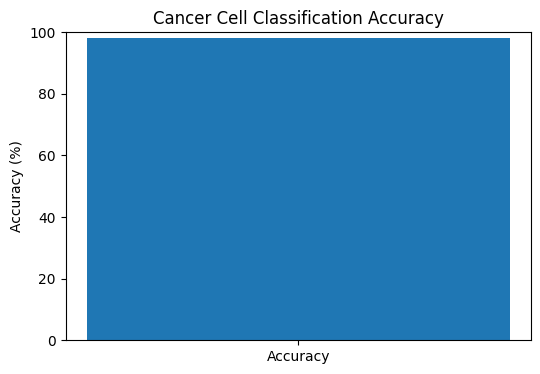

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(
    ["Accuracy"],
    [accuracy * 100]
)

plt.ylabel("Accuracy (%)")
plt.title("Cancer Cell Classification Accuracy")
plt.ylim(0, 100)

plt.show()

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Confusion Matrix:
[[41  1]
 [ 1 71]]


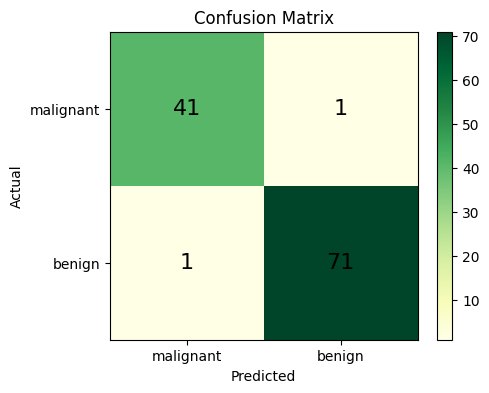

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))

plt.imshow(cm, cmap="YlGn")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], data.target_names)
plt.yticks([0, 1], data.target_names)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 fontsize=16)

plt.colorbar()
plt.show()

In [ ]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)[0]

print("Predicted Cancer Cell Type:",
      data.target_names[prediction])

Predicted Cancer Cell Type: malignant
